#### We do code and mark down here for part 1

# Question 1 

# Question 2

# Question 3


# 3.1 DEMONSTRATE POS TAGGING (3 marks)

In [1]:
# Import Libraries and Setup
import nltk
from textblob import TextBlob
from nltk.chunk import RegexpParser
import svgling 

# Download required NLTK data
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to C:\Users\Sarvein
[nltk_data]     Rao\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Sarvein Rao\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Sarvein Rao\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [16]:
# Load Input Sentence
with open("../Part_A/data/Data_2.txt", "r", encoding="utf-8") as f:
    sentence = f.read().strip()

print("Input Sentence:")
print(sentence)

Input Sentence:
The big black dog barked at the white cat and chased away.


# 3.1.1 NLTK POS Tagger

In [17]:
print("\n1.1 NLTK POS TAGGER\n")

# Tokenize the sentence into individual words/tokens
tokens = nltk.word_tokenize(sentence)
print(f"\nTokenized Words ({len(tokens)} tokens):")
print(tokens)

# POS tagging 
nltk_pos = nltk.pos_tag(tokens)

print("\n\nNLTK POS Tagging Output:")
print(f"{'Word':<15} {'POS Tag':<10} {'Description'}")


# Penn Treebank POS tag set
pos_meanings = {
    'DT': 'Determiner',
    'JJ': 'Adjective',
    'NN': 'Noun, singular',
    'NNS': 'Noun, plural',
    'VBD': 'Verb, past tense',
    'VB': 'Verb, base form',
    'VBG': 'Verb, gerund/present participle',
    'VBP': 'Verb, non-3rd person singular present',
    'IN': 'Preposition/subordinating conjunction',
    'CC': 'Coordinating conjunction',
    'RB': 'Adverb',
    '.': 'Punctuation',
    ',': 'Comma',
    'PRP': 'Personal pronoun'
}

# Iterate through each word-tag pair and display with description
for word, tag in nltk_pos:
    # Get the meaning of the tag, default to the tag itself if not in dictionary
    meaning = pos_meanings.get(tag, tag)
    print(f"{word:<15} {tag:<10} {meaning}")

# Display the complete list of tuples for reference
print("\n\nComplete Output (List of Tuples):")
print(nltk_pos)



1.1 NLTK POS TAGGER


Tokenized Words (13 tokens):
['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away', '.']


NLTK POS Tagging Output:
Word            POS Tag    Description
The             DT         Determiner
big             JJ         Adjective
black           JJ         Adjective
dog             NN         Noun, singular
barked          VBD        Verb, past tense
at              IN         Preposition/subordinating conjunction
the             DT         Determiner
white           JJ         Adjective
cat             NN         Noun, singular
and             CC         Coordinating conjunction
chased          VBD        Verb, past tense
away            RB         Adverb
.               .          Punctuation


Complete Output (List of Tuples):
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB'), ('.'

# 3.1.2 TextBlob POS Tagger

In [18]:
# Section 3.1.2: Part-of-Speech Tagging using TextBlob
print("\n\n3.1.2 TEXTBLOB POS TAGGER\n")

# Create a TextBlob object from the sentence
# TextBlob automatically tokenizes and tags the text
blob = TextBlob(sentence)

# Access the POS tags using the .tags property
textblob_pos = blob.tags

# Display formatted POS tagging results
print("TextBlob POS Tagging Output:")
print(f"{'Word':<15} {'POS Tag':<10} {'Description'}")

# Iterate through each word-tag pair and display with description
for word, tag in textblob_pos:
    # Get the meaning of the tag from the previously defined dictionary
    meaning = pos_meanings.get(tag, 'Unknown')
    print(f"{word:<15} {tag:<10} {meaning}")

# Display the complete list of tuples for reference
print("\n\nComplete Output:")
print(list(textblob_pos))



3.1.2 TEXTBLOB POS TAGGER

TextBlob POS Tagging Output:
Word            POS Tag    Description
The             DT         Determiner
big             JJ         Adjective
black           JJ         Adjective
dog             NN         Noun, singular
barked          VBD        Verb, past tense
at              IN         Preposition/subordinating conjunction
the             DT         Determiner
white           JJ         Adjective
cat             NN         Noun, singular
and             CC         Coordinating conjunction
chased          VBD        Verb, past tense
away            RB         Adverb


Complete Output:
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB')]


# 3.1.3 Regular Expression Tagger

In [ ]:
# Section 3.1.3: Part-of-Speech Tagging using Regular Expressions
print("\n3.1.3 REGULAR EXPRESSION TAGGER\n")

# Define pattern-tag pairs for rule-based POS tagging
patterns = [
    (r'.*ing$', 'VBG'),               # gerunds
    (r'.*ed$', 'VBD'),                # simple past 
    (r'.*es$', 'VBZ'),                # 3rd singular present
    (r'.*ould$', 'MD'),               # modals
    (r".*\'s$", 'NN$'),               # possessive nouns
    (r'.*s$', 'NNS'),                 # plural nouns
    (r'^-?[0-9]+(.[0-9]+)?$', 'CD'),  # cardinal number
    (r'^(The|the|a|an)$', 'DT'),      # determiners
    (r'^(and|or|but)$', 'CC'),        # coordinating conjunctions
    (r'^(at|in|on|to|from)$', 'IN'),  # prepositions
    (r'.*ly$', 'RB'),                 # adverbs
    (r'.*', 'NN')                   
]

# Create a Regular Expression Tagger with the defined patterns
regexp_tagger = nltk.RegexpTagger(patterns)

# Apply the regex tagger to the previously tokenized words
regex_pos = regexp_tagger.tag(tokens)

# Display formatted POS tagging results
print("Regular Expression POS Tagging Output:")
print(f"{'Word':<15} {'POS Tag':<10} {'Description'}")

# Iterate through each word-tag pair and display with description
for word, tag in regex_pos:
    # Get the meaning of the tag from the dictionary
    meaning = pos_meanings.get(tag, 'Unknown')
    print(f"{word:<15} {tag:<10} {meaning}")

# Display the complete list of tuples for reference
print("\n\nComplete Output:")
print(regex_pos)


3.1.3 REGULAR EXPRESSION TAGGER

Regular Expression POS Tagging Output:
Word            POS Tag    Description
The             DT         Determiner
big             NN         Noun, singular
black           NN         Noun, singular
dog             NN         Noun, singular
barked          VBD        Verb, past tense
at              IN         Preposition/subordinating conjunction
the             DT         Determiner
white           NN         Noun, singular
cat             NN         Noun, singular
and             CC         Coordinating conjunction
chased          VBD        Verb, past tense
away            NN         Noun, singular
.               NN         Noun, singular


Complete Output:
[('The', 'DT'), ('big', 'NN'), ('black', 'NN'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'NN'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'NN'), ('.', 'NN')]


# 3.2 Explanation 

# 3.3 Draw Parse Trees



METHOD 1: CHUNK PARSER

Parse Tree Output:
(S
  (NP The/DT big/JJ black/JJ dog/NN)
  (VP barked/VBD)
  (PP at/IN (NP the/DT white/JJ cat/NN))
  and/CC
  (VP chased/VBD away/RB)
  ./.)


SVG Visualization (svgling):


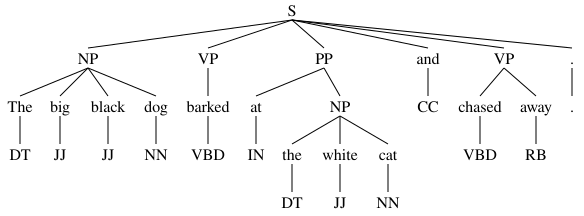

In [67]:
# QUESTION 3: PARSE TREES

# METHOD 1: Chunking using Chunk Parser
print("\n\nMETHOD 1: CHUNK PARSER\n")

# Define grammar rules for chunking using regular expressions
chunk_grammar = r"""
    NP: {<DT>?<JJ>*<NN.*>+}       
    VP: {<VB.*><RB>?}              
    VP: {<VB.*><IN><NP>}           
    PP: {<IN><NP>}                 
"""

# Create a chunk parser with the defined grammar rules
chunk_parser = RegexpParser(chunk_grammar)

# Parse the POS-tagged tokens to identify and group phrases
# Returns a tree structure with labeled chunks
chunked_tree = chunk_parser.parse(nltk_pos)

# Display the tree structure in text format
print("Parse Tree Output:")
print(chunked_tree)


# Display with svgling for beautiful SVG visualization
print("\n\nSVG Visualization (svgling):")
display(chunked_tree)



METHOD 2: CONTEXT-FREE GRAMMAR PARSER



Parse Tree Output:
(S
  (NP (DT The) (ADJP (JJ big) (JJ black)) (NN dog))
  (VP
    (VBD barked)
    (PP (IN at) (NP (DT the) (ADJP (JJ white)) (NN cat))))
  (CC and)
  (VP (VBD chased) (RB away)))

SVG Visualization (svgling):


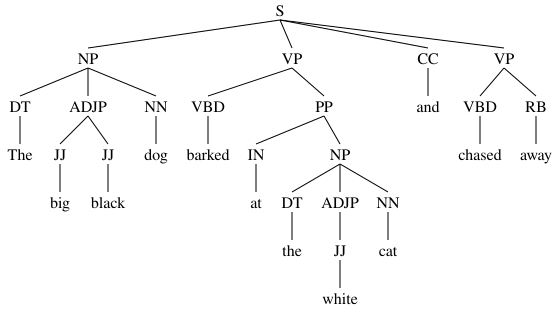

In [68]:
# METHOD 2: Parsing using Context-Free Grammar (CFG)
print("\n\nMETHOD 2: CONTEXT-FREE GRAMMAR PARSER\n")

with open("../Part_A/data/Data_2.txt", "r", encoding="utf-8") as f:
    sentence = f.read().strip()

tokens = nltk.word_tokenize(sentence)
nltk_pos = nltk.pos_tag(tokens)

# Define a context-free grammar with production rules
cfg_grammar = nltk.CFG.fromstring("""
    S -> NP VP                     
    S -> NP VP CC VP               
    
    NP -> DT ADJP NN               
    NP -> DT NN                    
    
    ADJP -> JJ JJ                  
    ADJP -> JJ                     
    
    VP -> VBD PP                   
    VP -> VBD RB                   
    
    PP -> IN NP                    
    
    DT -> 'The' | 'the'            
    JJ -> 'big' | 'black' | 'white'
    NN -> 'dog' | 'cat'
    VBD -> 'barked' | 'chased'
    IN -> 'at'
    CC -> 'and'
    RB -> 'away'
""")

# Remove punctuation from tokens for cleaner parsing
parse_tokens = [word for word in tokens if word != '.']

# Create a chart parser with the defined CFG grammar
parser = nltk.ChartParser(cfg_grammar)

# Parse the tokens and generate all possible parse trees
parse_trees = list(parser.parse(parse_tokens))


# Display each parse tree with both text and visual formats
for i, tree in enumerate(parse_trees, 1):
    print(f"\n\nParse Tree Output:")
    print(tree)
    print("\nSVG Visualization (svgling):")
    display(tree)

# Question 4

In [5]:
#1 Open the file and read everything inside it as one big string

with open("../Part_A/data/Data_3.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(text)


Training Corpus
~~~~~~~~~~~~~
<s> He read a book </s>
<s> I read a different book </s>
<s> He read a book by Danielle </s>

Calculate sentence probability for the following sentence
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
<s> I read a different book by Danielle </s>


2) Step 2 — Preprocess (keep <s> and </s>)
What preprocessing we do (simple + safe)

We:

split by lines (each line is one sentence)

split each sentence by spaces (so <s> and </s> stay as tokens)

remove any empty pieces

In [6]:
# 2) Split into lines (sentences)
lines = [line.strip() for line in text.splitlines() if line.strip()]

# 3) Split each line into tokens by spaces (keeps <s> and </s>)
sentences = [line.split() for line in lines]

print(sentences)


[['Training', 'Corpus'], ['~~~~~~~~~~~~~'], ['<s>', 'He', 'read', 'a', 'book', '</s>'], ['<s>', 'I', 'read', 'a', 'different', 'book', '</s>'], ['<s>', 'He', 'read', 'a', 'book', 'by', 'Danielle', '</s>'], ['Calculate', 'sentence', 'probability', 'for', 'the', 'following', 'sentence'], ['~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~'], ['<s>', 'I', 'read', 'a', 'different', 'book', 'by', 'Danielle', '</s>']]


In [8]:
from collections import Counter

# Flatten all tokens into one list
all_tokens = [tok for sent in sentences for tok in sent]

# Count unigrams (single tokens)
unigram_counts = Counter(all_tokens)

# Count bigrams (pairs)
bigram_counts = Counter()
for sent in sentences:
    for i in range(len(sent) - 1):
        bigram_counts[(sent[i], sent[i+1])] += 1

print("count(<s>) =", unigram_counts["<s>"])
print("count(<s>, I) =", bigram_counts[("<s>", "I")])


count(<s>) = 4
count(<s>, I) = 2


In [9]:
def sentence_probability(tokens, unigram_counts, bigram_counts, V, smoothing=False):
    prob = 1.0

    for i in range(1, len(tokens)):
        prev_word = tokens[i-1]
        word = tokens[i]

        bigram = (prev_word, word)

        if smoothing:
            numerator = bigram_counts[bigram] + 1
            denominator = unigram_counts[prev_word] + V
        else:
            numerator = bigram_counts[bigram]
            denominator = unigram_counts[prev_word]

            # If a bigram was never seen, probability becomes 0
            if numerator == 0:
                return 0.0

        prob *= numerator / denominator

    return prob


In [10]:
test_sentence = "<s> I read a different book by Danielle </s>".split()

V = len(set(all_tokens))  # vocabulary size

unsmoothed = sentence_probability(test_sentence, unigram_counts, bigram_counts, V, smoothing=False)
smoothed = sentence_probability(test_sentence, unigram_counts, bigram_counts, V, smoothing=True)

print("Vocabulary size V =", V)
print("Unsmoothed probability =", unsmoothed)
print("Smoothed probability   =", smoothed)


Vocabulary size V = 20
Unsmoothed probability = 0.125
Smoothed probability   = 1.4069643627057575e-07


# Question 5 ( Indivdual )

##### Alternative Approach Implementation 

Each student must independently implement an alternative technique for the task Q1 and compare it with the group’s approach.

•	Implement tokenization using an alternative approach. (3 marks)

•	Compare and contrast the alternative approach with the group’s approach. (2 marks)

•	Explain why the alternative approach is better, worse, or just different. (5 marks) 


# Sarvein

#  Q5. Alternative Approach Implementation - TextBlob Tokenization
Alternative tokenization using TextBlob 

In [69]:
# Import Libraries

from textblob import TextBlob
import string


In [70]:
# Load Input Sentence
with open("../Part_A/data/Data_1.txt", "r", encoding="utf-8") as f:
    sentence = f.read().strip()


print("INPUT SENTENCE:")
print(sentence)


INPUT SENTENCE:
Classification is the task of choosing the correct class label for a given input. In basic
classification tasks, each input is considered in isolation from all other inputs, and the set of labels is defined in advance. The basic classification task has a number of interesting variants. For example, in multiclass classification, each instance may be assigned multiple labels; in open-class classification, the set of labels is not defined in advance; and in sequence classification, a list of inputs are jointly classified.


In [71]:
# PART 1: Word Tokenization using TextBlob (2 marks)
print("PART 1: WORD TOKENIZATION USING TEXTBLOB")

# Create TextBlob object
blob = TextBlob(sentence)

# Tokenize words
tokens = blob.words

print(f"\nTotal number of tokens: {len(tokens)}\n")
print("Tokenized words:")
print(tokens)
print("\n")

PART 1: WORD TOKENIZATION USING TEXTBLOB

Total number of tokens: 82

Tokenized words:
['Classification', 'is', 'the', 'task', 'of', 'choosing', 'the', 'correct', 'class', 'label', 'for', 'a', 'given', 'input', 'In', 'basic', 'classification', 'tasks', 'each', 'input', 'is', 'considered', 'in', 'isolation', 'from', 'all', 'other', 'inputs', 'and', 'the', 'set', 'of', 'labels', 'is', 'defined', 'in', 'advance', 'The', 'basic', 'classification', 'task', 'has', 'a', 'number', 'of', 'interesting', 'variants', 'For', 'example', 'in', 'multiclass', 'classification', 'each', 'instance', 'may', 'be', 'assigned', 'multiple', 'labels', 'in', 'open-class', 'classification', 'the', 'set', 'of', 'labels', 'is', 'not', 'defined', 'in', 'advance', 'and', 'in', 'sequence', 'classification', 'a', 'list', 'of', 'inputs', 'are', 'jointly', 'classified']




### Remma